
[ROC] A processar a classe 'normal'...


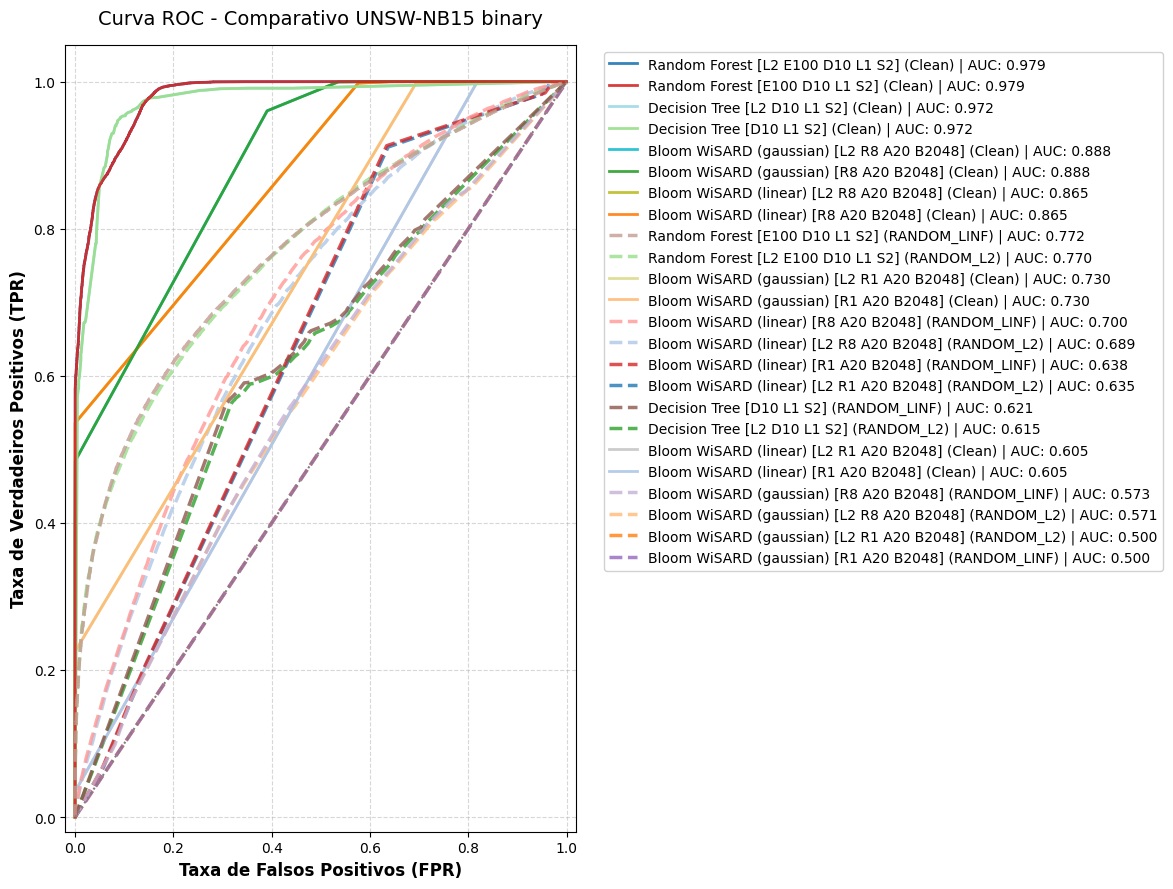

✅ Gráfico limpo gerado com sucesso!

[PR] A processar a classe 'normal'...


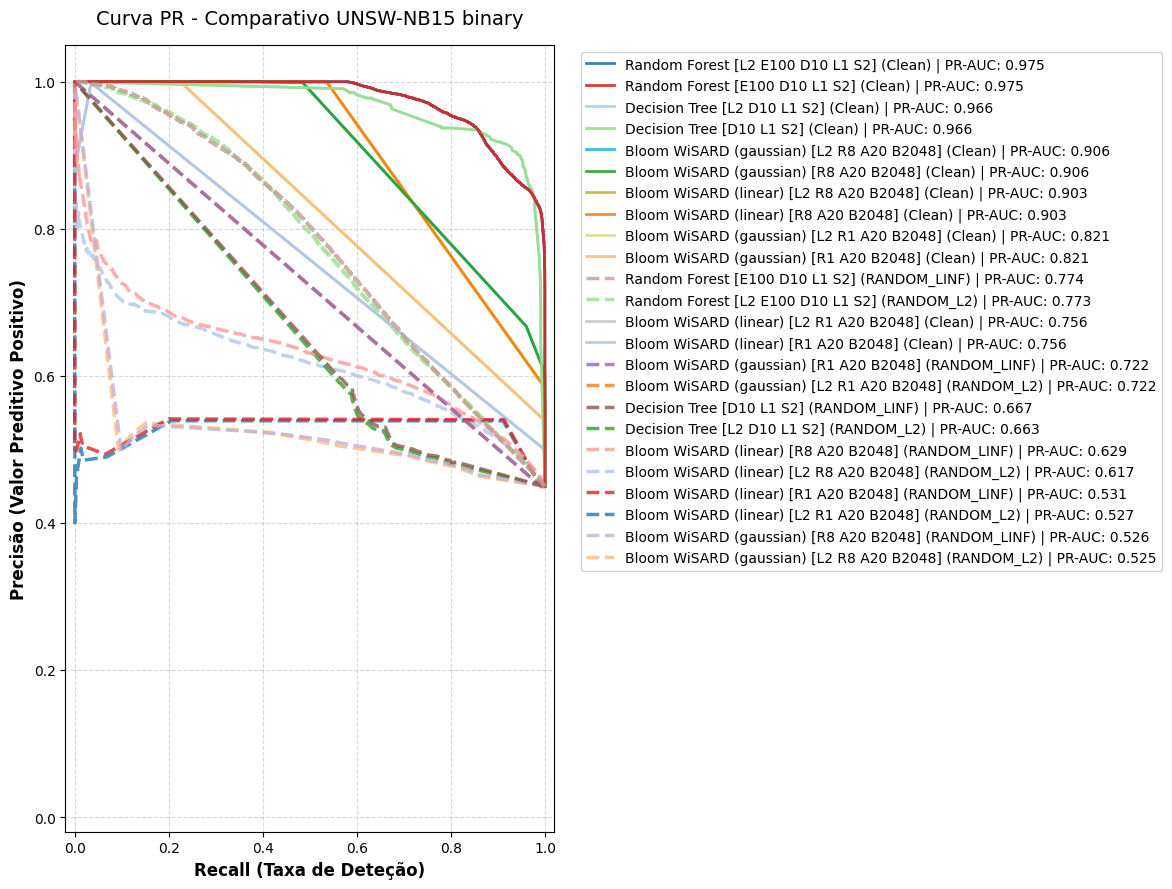

✅ Gráfico limpo gerado com sucesso!


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import os
import itertools

# ==========================================
# FUNÇÃO GERADORA DE GRÁFICOS (ROC e PR) - SEM DUPLICAÇÕES
# ==========================================
def plot_comparative_curves(file_paths, curve_type='ROC', target_class='normal', title_suffix=""):
    plt.figure(figsize=(12, 9))
    
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(20)]
    
    print(f"\n[{curve_type.upper()}] A processar a classe '{target_class}'...")

    linhas_desenhadas = 0
    legend_data = [] 
    
    # Conjunto para rastrear quais curvas Clean já foram plotadas
    clean_lines_plotted = set()

    for idx, file_path in enumerate(file_paths):
        full_path = os.path.join("curves_data", file_path)
        
        if not os.path.exists(full_path):
            continue
            
        data = np.load(full_path, allow_pickle=True)
        y_true = data['y_true']
        y_prob_clean = data['y_prob_clean']
        y_prob_adv = data['y_prob_adv']
        model_name = str(data['model_name'])
        attack_name = str(data['attack_name'])
        class_names = [str(c).lower() for c in data['class_names']]
        
        try:
            class_idx = next(i for i, name in enumerate(class_names) if target_class in name)
        except StopIteration:
            continue
            
        y_true_binary = (y_true == class_idx).astype(int)
        
        if len(y_prob_clean.shape) == 1 or y_prob_clean.shape[1] == 1:
            prob_c = y_prob_clean if class_idx == 1 else 1 - y_prob_clean
            prob_a = y_prob_adv if class_idx == 1 else 1 - y_prob_adv
        else:
            prob_c = y_prob_clean[:, class_idx]
            prob_a = y_prob_adv[:, class_idx]
            
        color = colors[linhas_desenhadas % len(colors)]
        
        # ---> NOVO: Extração de hiperparâmetros à prova de balas <---
        import re # Certifique-se de que a biblioteca Regex é usada
        
        file_name_no_ext = os.path.basename(file_path).replace('.npz', '')
        parts = file_name_no_ext.split('_')
        
        # Filtra apenas os pedaços que sejam a Letra do Hiperparâmetro seguida de números (Ex: R10, A20, B1024, D10)
        params = [p for p in parts if re.match(r'^[RABEDLS]\d+$', p)]
        params_str = " ".join(params)
        
        # Constrói a legenda. Se não encontrar parâmetros, esconde os colchetes.
        if params_str:
            legenda_base = f"{model_name} [{params_str}]"
        else:
            legenda_base = f"{model_name}"
            
        # A legenda base agora diz a configuração exata!
        legenda_base = f"{model_name} [{params_str}]"
        
        # Identificador único para a curva limpa deste modelo específico
        clean_id = legenda_base
        
        # --- CURVA ROC ---
        if curve_type.upper() == 'ROC':
            # Plota a linha Clean APENAS SE ainda não foi plotada para este modelo
            if clean_id not in clean_lines_plotted:
                fpr_c, tpr_c, _ = roc_curve(y_true_binary, prob_c)
                auc_c = auc(fpr_c, tpr_c)
                line_c, = plt.plot(fpr_c, tpr_c, color=colors[(linhas_desenhadas + 15) % 20], linestyle='-', lw=2, alpha=0.9)
                label_c = f"{legenda_base} (Clean) | AUC: {auc_c:.3f}"
                legend_data.append((auc_c, line_c, label_c))
                clean_lines_plotted.add(clean_id) # Marca como desenhada
            
            # Linha Adversarial (Sempre Plota)
            fpr_a, tpr_a, _ = roc_curve(y_true_binary, prob_a)
            auc_a = auc(fpr_a, tpr_a)
            line_a, = plt.plot(fpr_a, tpr_a, color=color, linestyle='--', lw=2.5, alpha=0.8)
            label_a = f"{legenda_base} ({attack_name}) | AUC: {auc_a:.3f}"
            legend_data.append((auc_a, line_a, label_a))

        # --- CURVA PR ---
        elif curve_type.upper() == 'PR':
            # Plota a linha Clean APENAS SE ainda não foi plotada para este modelo
            if clean_id not in clean_lines_plotted:
                prec_c, rec_c, _ = precision_recall_curve(y_true_binary, prob_c)
                auc_c = auc(rec_c, prec_c)
                line_c, = plt.plot(rec_c, prec_c, color=colors[(linhas_desenhadas + 15) % 20], linestyle='-', lw=2, alpha=0.9)
                label_c = f"{legenda_base} (Clean) | PR-AUC: {auc_c:.3f}"
                legend_data.append((auc_c, line_c, label_c))
                clean_lines_plotted.add(clean_id) # Marca como desenhada
            
            # Linha Adversarial (Sempre Plota)
            prec_a, rec_a, _ = precision_recall_curve(y_true_binary, prob_a)
            auc_a = auc(rec_a, prec_a)
            line_a, = plt.plot(rec_a, prec_a, color=color, linestyle='--', lw=2.5, alpha=0.8)
            label_a = f"{legenda_base} ({attack_name}) | PR-AUC: {auc_a:.3f}"
            legend_data.append((auc_a, line_a, label_a))
            
        linhas_desenhadas += 1

    if len(legend_data) == 0:
        print(f"❌ Nenhum ficheiro válido foi encontrado.")
        plt.close()
        return

    # Ordenação da Legenda (Maior AUC primeiro)
    legend_data.sort(key=lambda x: x[0], reverse=True)
    sorted_handles = [item[1] for item in legend_data]
    sorted_labels = [item[2] for item in legend_data]

    # Customização do Gráfico
    if curve_type.upper() == 'ROC':
        plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':')
        plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
        plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12, fontweight='bold')
        loc_padrao = "lower right"
    elif curve_type.upper() == 'PR':
        plt.xlabel('Recall (Taxa de Deteção)', fontsize=12, fontweight='bold')
        plt.ylabel('Precisão (Valor Preditivo Positivo)', fontsize=12, fontweight='bold')
        loc_padrao = "lower left"

    if len(legend_data) > 4: 
        plt.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.04, 1), loc="upper left", fontsize=10, framealpha=0.9)
    else:
        plt.legend(sorted_handles, sorted_labels, loc=loc_padrao, fontsize=10, framealpha=0.9)

    plt.title(f'Curva {curve_type.upper()} - {title_suffix}', fontsize=14, pad=15)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.05])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    nome_ficheiro = f"grafico_{curve_type.upper()}_{title_suffix.replace(' ', '_')}.png"
    plt.savefig(nome_ficheiro, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Gráfico limpo gerado com sucesso!")

# ==========================================
# PAINEL DE BUSCA EM LOTE (BATCH SEARCH)
# ==========================================
if __name__ == "__main__":
    
    # 1. ESCOPO GERAL (Pode colocar vários na lista)
    DATASETS = ['UNSW-NB15']            # 'Bot-IoT' ou 'UNSW-NB15'
    MODES = ['binary']               # 'binary' ou 'multiclass'
    ATTACKS = ['RANDOM_L2', 'RANDOM_LINF']  # 'FGSM', 'RANDOM_LINF' ou 'RANDOM_L2'
    
    # 2. SELEÇÃO DE MODELOS (Coloque True para incluir no gráfico)
    INCLUIR_WISARD = True
    INCLUIR_DT = True
    INCLUIR_RF = True
    
    # 3. HIPERPARÂMETROS DA WISARD (Listas)
    WISARD_ENCODINGS = ['linear', 'gaussian']
    WISARD_RES = [1, 8]
    WISARD_ADDR = [20]
    WISARD_BLOOM = [2048]
    # WISARD_HASH = [3]
    
    # 4. HIPERPARÂMETROS DA DECISION TREE
    DT_DEPTH = [10]
    DT_LEAF = [1]
    DT_SPLIT = [2]
    
    # 5. HIPERPARÂMETROS DA RANDOM FOREST
    RF_EST = [100]
    RF_DEPTH = [10]
    RF_LEAF = [1]
    RF_SPLIT = [2]
    
    # ==========================================
    # CONSTRUTOR AUTOMÁTICO DE FICHEIROS
    # ==========================================
    arquivos_para_comparar = []
    
    # Faz todas as combinações matemáticas das listas que você preencheu acima
    for d, m, a in itertools.product(DATASETS, MODES, ATTACKS):
        
        if INCLUIR_WISARD:
            for enc, r, addr, b in itertools.product(WISARD_ENCODINGS, WISARD_RES, WISARD_ADDR, WISARD_BLOOM):
                arquivos_para_comparar.append(f"bloom_{d}_{m}_{enc}_{a}_R{r}_A{addr}_B{b}.npz")
                
        if INCLUIR_DT:
            for dep, leaf, split in itertools.product(DT_DEPTH, DT_LEAF, DT_SPLIT):
                arquivos_para_comparar.append(f"dt_{d}_{m}_{a}_D{dep}_L{leaf}_S{split}.npz")
                
        if INCLUIR_RF:
            for est, dep, leaf, split in itertools.product(RF_EST, RF_DEPTH, RF_LEAF, RF_SPLIT):
                arquivos_para_comparar.append(f"rf_{d}_{m}_{a}_E{est}_D{dep}_L{leaf}_S{split}.npz")
                
    # ==========================================
    # PLOTAGEM
    # ==========================================
    TITULO_DO_CENARIO = f"Comparativo {DATASETS[0]} {MODES[0]}"
    
    # Gera a Curva ROC
    plot_comparative_curves(arquivos_para_comparar, curve_type='ROC', target_class='normal', title_suffix=TITULO_DO_CENARIO)
    
    # Gera a Curva PR
    plot_comparative_curves(arquivos_para_comparar, curve_type='PR', target_class='normal', title_suffix=TITULO_DO_CENARIO)